In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymc as pm
import arviz as az
from scipy.stats import norm

In [271]:
data = pd.read_csv("russia_mar2020_sep2020.csv")
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')
first_date = data['date'].min()
data['days_since_start'] = (data['date'] - first_date).dt.days
new_cases = data['new_cases'].values
total_cases = data['total_cases'].values
data.head(10)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,days_since_start
0,RUS,Europe,Russia,2020-03-03,3.0,1.0,0.143,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,0
1,RUS,Europe,Russia,2020-03-04,3.0,1.0,0.143,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,1
2,RUS,Europe,Russia,2020-03-05,4.0,1.0,0.286,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,2
3,RUS,Europe,Russia,2020-03-06,13.0,9.0,1.571,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,3
4,RUS,Europe,Russia,2020-03-07,13.0,1.0,1.571,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,4
5,RUS,Europe,Russia,2020-03-08,17.0,4.0,2.143,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,5
6,RUS,Europe,Russia,2020-03-09,17.0,1.0,2.000,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,6
7,RUS,Europe,Russia,2020-03-10,20.0,3.0,2.429,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,7
8,RUS,Europe,Russia,2020-03-11,20.0,1.0,2.429,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,8
9,RUS,Europe,Russia,2020-03-12,28.0,8.0,3.429,0.0,0.0,0.0,...,0.1,431.297,6.18,23.4,58.3,0.0,8.05,72.58,0.816,9


Text(0, 0.5, 'Заболевших за день')

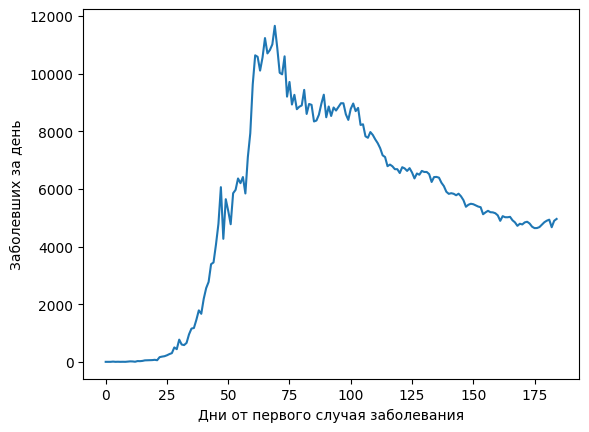

In [272]:
days = data["days_since_start"]
infected = data["new_cases"]
plt.plot(days, infected)
plt.xlabel('Дни от первого случая заболевания')
plt.ylabel('Заболевших за день')

Text(0, 0.5, 'Общее количество заболевших')

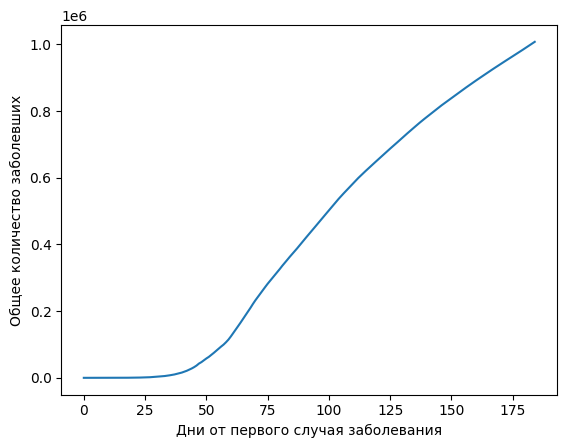

In [273]:
days = data["days_since_start"]
total_infected = data["total_cases"]
plt.plot(days, total_infected)
plt.xlabel('Дни от первого случая заболевания')
plt.ylabel('Общее количество заболевших')

In [274]:
train_data = data[['days_since_start', 'total_cases', 'new_cases']].head(60).copy()
train_data.head(10)
test_data = data[['days_since_start', 'total_cases', 'new_cases']].iloc[60:90].copy()
test_data.head(10)

,days_since_start,total_cases,new_cases
60,60,124054.0,9623.0
61,61,134687.0,10633.0
62,62,145268.0,10581.0
63,63,155370.0,10102.0
64,64,165929.0,10559.0
65,65,177160.0,11231.0
66,66,187859.0,10699.0
67,67,198676.0,10817.0
68,68,209688.0,11012.0
69,69,221344.0,11656.0


Text(0, 0.5, 'Общее количество заболевших')

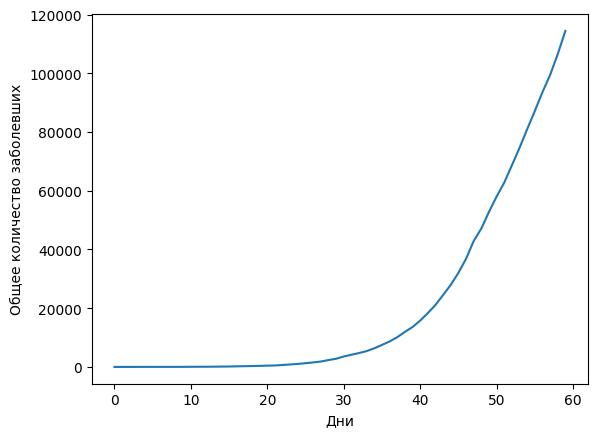

In [275]:
train_days = train_data["days_since_start"]
train_total_infected = train_data["total_cases"]
plt.plot(train_days, train_total_infected)
plt.xlabel('Дни')
plt.ylabel('Общее количество заболевших')

In [276]:
Max = data["new_cases"].max()
Max

np.float64(11656.0)

In [277]:
#Для работы с гауссианом и линейной регрессией, используем возможность произвольной константы и произвольной экспонеольной квадратичной функции от t
##Интеграл от экспоненты напрямую линеризовать крайне сложно, используем производную. Общее число заболевших это интеграл от количества новых случаев, то количество новых случаев в день является производной, то есть самим гауссианом

In [278]:
#Функцию от новых случаев можно линеризовать

In [279]:
train_data['new_cases_log'] = np.log(train_data['new_cases'] + 1e-6)
new_cases_log = train_data["new_cases_log"].copy()

In [280]:
# with pm.Model() as bayesian_model:
#     X_shared = pm.Data('X_shared', X_train)
    
#     beta0 = pm.Normal('beta0', mu=0, sigma=100)
#     beta1 = pm.Normal('beta1', mu=0, sigma=10)
#     beta2 = pm.Normal('beta2', mu=0, sigma=1)

#     map_estimate = pm.find_MAP()
#     noise_sigma_map_val = np.sqrt(1 / map_estimate.get('tau', 1.0)) if 'tau' in map_estimate else 1.0
#     sigma = pm.HalfNormal('sigma', sigma=noise_sigma_map_val * 2)

#     mu = beta0 + beta1 * X_shared[:, 0] + beta2 * X_shared[:, 1]

#     likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=y_train)

#     trace = pm.sample(2000, tune=1000, cores=1, return_inferencedata=True)

In [281]:
X = np.column_stack([np.ones(60), train_days**2, train_days])
model = LinearRegression(fit_intercept=False)
model.fit(X, new_cases_log)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [282]:
coefs = model.coef_
c = coefs[0]
a = coefs[1]
b = coefs[2]

print(f"Коэффициенты model.coef_: {coefs}")

Коэффициенты model.coef_: [-0.50127437 -0.00221668  0.29193533]


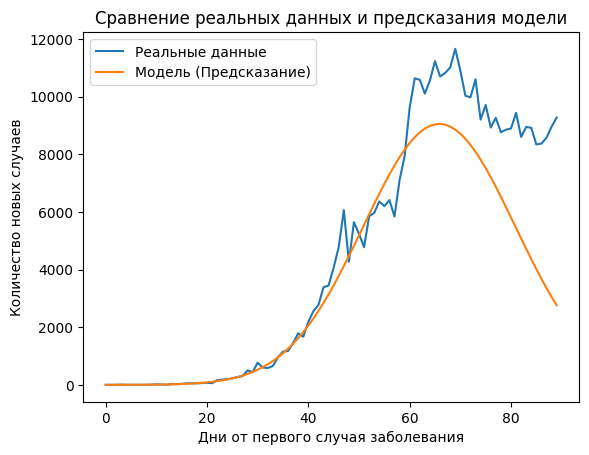

In [297]:
def exp_calc_logistic(x_days):
    return np.exp(c + a * x_days**2 + b * x_days)

# Используем данные за первые 90 дней
data_90_days = data.head(90)
real_days_90 = data_90_days['days_since_start'].values
real_cases_90_days = data_90_days['new_cases'].values

# Предсказания для реальных дней из данных
y_predict = exp_calc_logistic(real_days_90)

plt.plot(real_days_90, real_cases_90_days, label='Реальные данные')
plt.plot(real_days_90, y_predict, label='Модель (Предсказание)')
plt.xlabel('Дни от первого случая заболевания')
plt.ylabel('Количество новых случаев')
plt.title('Сравнение реальных данных и предсказания модели')
plt.legend()
plt.show()

In [284]:
#Модель выдает приемлимую точность на первых 60 днях, потом сильно промахивается относительно реальных данных, при использовании больших тренировочных данных, можно получить лучшую точность, но я считаю, что функция нормального распределения не идеальный вариант для такой задачи

In [285]:
test_days = train_days.values
predict_cases = c + a * test_days**2 + b * test_days
noise_var = np.mean((new_cases_log - predict_cases)**2)
print(f'Дисперсия шума: {noise_var}') 
print(f'Стандартное отклонение: {noise_var**(1/2)}') 

Дисперсия шума: 0.20754038327351407
Стандартное отклонение: 0.4555660032020762


In [286]:
x_3 = np.column_stack([np.ones(60), train_days**2, train_days])
exp_val = [c, a, b]
cov_matrix = noise_var * np.linalg.inv(x_3.T @ x_3)
cov_matrix

array([[ 2.91445525e-02,  2.74379142e-05, -1.95906708e-03],
       [ 2.74379142e-05,  4.81085580e-08, -2.83840492e-06],
       [-1.95906708e-03, -2.83840492e-06,  1.78999115e-04]])

In [287]:
exp_val

[np.float64(-0.5012743692299955),
 np.float64(-0.0022166776593630505),
 np.float64(0.2919353269134377)]

In [288]:
#получено многомерное нормальное распределение трёх параметров модели

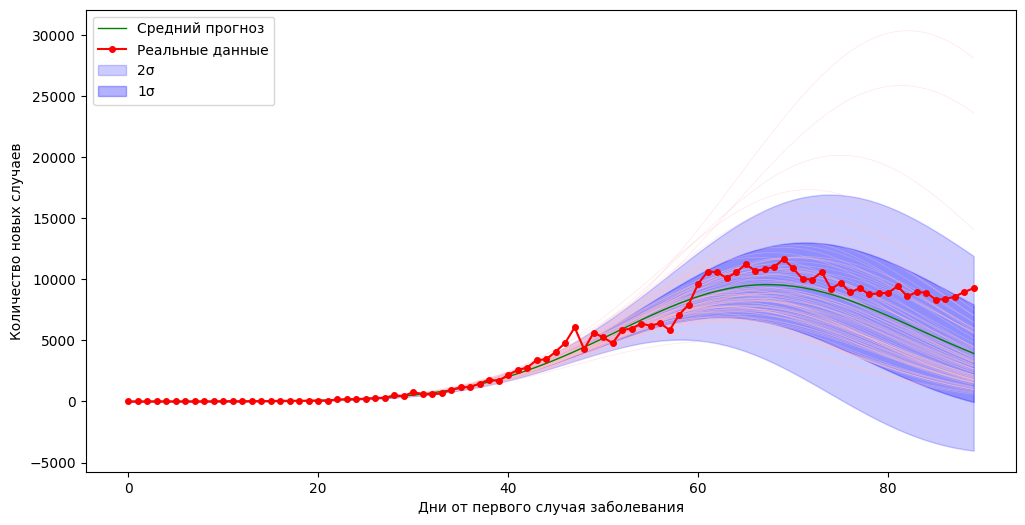

In [296]:
N = 100

data_90_days = data.head(90)
days_to_predict = data_90_days["days_since_start"].values

samples = np.random.multivariate_normal(mean=exp_val, cov=cov_matrix, size=N)

sample_c = samples[:, 0][:, None]
sample_a = samples[:, 1][:, None]
sample_b = samples[:, 2][:, None]

predictions_all = np.exp(sample_c + sample_a * days_to_predict**2 + sample_b * days_to_predict)

mean_prediction = predictions_all.mean(axis=0)
std_prediction = predictions_all.std(axis=0)

plt.figure(figsize=(12, 6))

plt.plot(days_to_predict, predictions_all.T, color='pink', alpha=0.4, linewidth=0.5)
plt.plot(days_to_predict, mean_prediction, 'g', linewidth=1, label='Средний прогноз')

new_cases_90 = data_90_days["new_cases"].values

plt.plot(days_to_predict, new_cases_90, 'ro-', markersize=4, label='Реальные данные')

plt.fill_between(days_to_predict, mean_prediction - 2*std_prediction,
                                     mean_prediction + 2*std_prediction,
                                     alpha=0.2, color='blue', label='2σ')
plt.fill_between(days_to_predict, mean_prediction - std_prediction,
                                     mean_prediction + std_prediction,
                                     alpha=0.3, color='blue', label='1σ')

plt.xlabel('Дни от первого случая заболевания')
plt.ylabel('Количество новых случаев')
plt.legend()
plt.show()

In [299]:
#Семплирование показало, что модель не очень точно предугадывает график, но весьма неплохо, если учитывая малое кол-во данных для тренировки,
#Судя по графику, в начале предсказания хорошо попадают по реальным данным, но после пика, наша функция идет на спад, когда реальные данные ещё не

In [300]:
#Выводы: Модель хорошо показывает результаты на 60-70, но крайне неточна далее, так как доходит до своего максимума слишкомс рано